
## Adversarial Attacks on Deep Learning Models
 
**Objective:** To demonstrate how small, intentional perturbations can deceive a state-of-the-art computer vision model.
 
 **Attacks implemented:**
 1. **FGSM (Fast Gradient Sign Method):** A fast, one-step attack.
 2. **PGD (Projected Gradient Descent):** An iterative, stronger version of FGSM.
 3. **C&W (Carlini & Wagner):** A powerful optimization-based attack.




In [33]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import torchattacks

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


 ## 2. Load Pre-trained Model
 We will use ResNet18, pre-trained on the ImageNet dataset.

In [34]:
weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).to(device)
class_names = weights.meta["categories"]
model.eval() # Crucial: Set to evaluation mode (disables Dropout/BatchNorm updates)



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 3. Utility Functions
We need functions to download images and visualize the results.

In [35]:


def download_image(url):
    """Downloads an image from a URL."""
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    return img

def preprocess_image(img):
    """Prepares image for ResNet18 (Resize, Tensor, Normalize)."""
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return transform(img).unsqueeze(0).to(device)

def denormalize(tensor):
    """Converts a normalized tensor back to a viewable image format."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)
    return tensor.squeeze().cpu().permute(1, 2, 0).numpy()

def plot_results(original, adv, orig_label, adv_label, orig_name, adv_name, title):
    """Plots the original and adversarial images side-by-side."""
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    ax[0].imshow(denormalize(original.squeeze()))
    ax[0].set_title(f"Original\n{orig_name} (ID: {orig_label})")
    ax[0].axis('off')
    
    ax[1].imshow(denormalize(adv.squeeze()))
    ax[1].set_title(f"Adversarial\n{adv_name} (ID: {adv_label})")
    ax[1].axis('off')
    
    plt.suptitle(title, fontsize=16)
    plt.show()



## 4. Execution: The Attack Demo

Step 1: Download a test image (A Golden Retriever)
You can replace this URL with any clear image of an object.

Original Predicted Class: golden retriever (ID: 207)

Running FGSM Attack...
FGSM Predicted Class: Airedale (ID: 191)


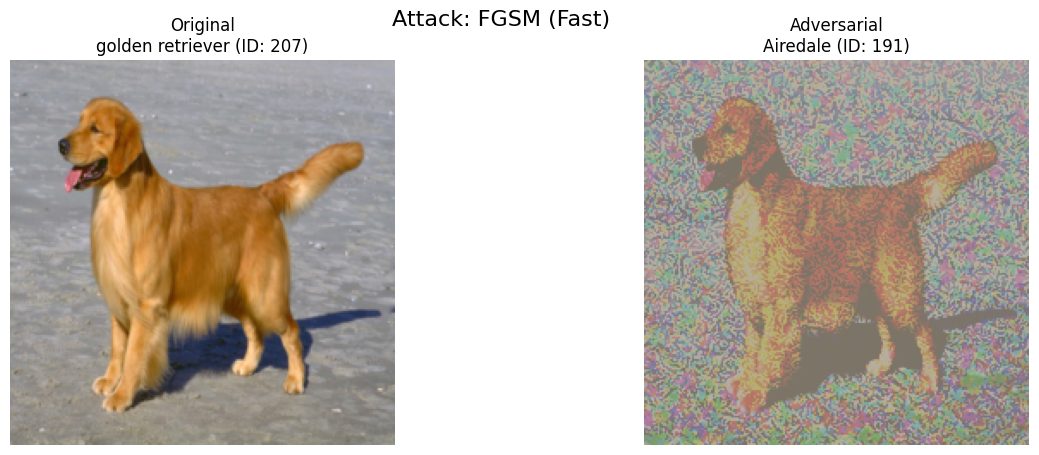


Running PGD Attack (Iterative)...
PGD Predicted Class: vizsla (ID: 211)


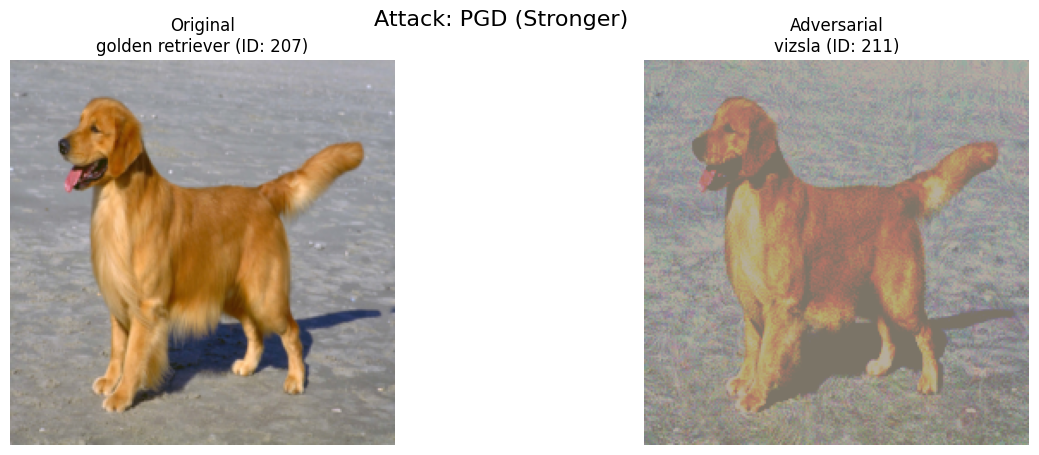


Running C&W Attack (Optimization-based)...
C&W Predicted Class: bloodhound (ID: 163)


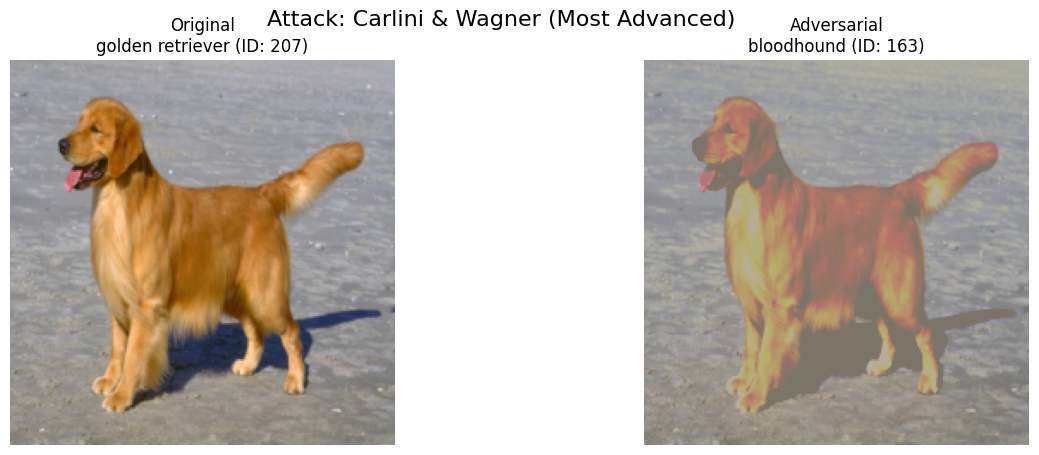

In [39]:

if "class_names" not in globals():
    class_names = models.ResNet18_Weights.IMAGENET1K_V1.meta["categories"]

image_path = "samples/dog.jpg"
# image_path = "samples/cat.png"
raw_image = Image.open(image_path).convert('RGB')

# Step 2: Preprocess
input_tensor = preprocess_image(raw_image)

# Step 3: Get Ground Truth Prediction
with torch.no_grad():
    output = model(input_tensor)
    _, pred_idx = torch.max(output, 1)
    label_tensor = pred_idx.clone().detach()
    orig_label = label_tensor.item()
    orig_name = class_names[orig_label]

print(f"Original Predicted Class: {orig_name} (ID: {orig_label})")

# --- ATTACK 1: FGSM ---
print("\nRunning FGSM Attack...")
fgsm_attack = torchattacks.FGSM(model, eps=100/255)
adv_fgsm = fgsm_attack(input_tensor, label_tensor)

with torch.no_grad():
    _, fgsm_label = torch.max(model(adv_fgsm), 1)
    fgsm_label = fgsm_label.item()
    fgsm_name = class_names[fgsm_label]

print(f"FGSM Predicted Class: {fgsm_name} (ID: {fgsm_label})")
plot_results(input_tensor, adv_fgsm, orig_label, fgsm_label, orig_name, fgsm_name, "Attack: FGSM (Fast)")

# --- ATTACK 2: PGD ---
print("\nRunning PGD Attack (Iterative)...")
# PGD is much stronger as it takes multiple small steps
pgd_attack = torchattacks.PGD(model, eps=64/255, alpha=2/255, steps=100)
adv_pgd = pgd_attack(input_tensor, label_tensor)

with torch.no_grad():
    _, pgd_label = torch.max(model(adv_pgd), 1)
    pgd_label = pgd_label.item()
    pgd_name = class_names[pgd_label]

print(f"PGD Predicted Class: {pgd_name} (ID: {pgd_label})")
plot_results(input_tensor, adv_pgd, orig_label, pgd_label, orig_name, pgd_name, "Attack: PGD (Stronger)")

# --- ATTACK 3: Carlini & Wagner (C&W) ---
print("\nRunning C&W Attack (Optimization-based)...")
# Note: C&W can be slow because it solves an optimization problem per image.
# We use the L2 version here.
cw_attack = torchattacks.CW(model, c=1, kappa=0.5, steps=100, lr=0.01)
adv_cw = cw_attack(input_tensor, label_tensor)

with torch.no_grad():
    _, cw_label = torch.max(model(adv_cw), 1)
    cw_label = cw_label.item()
    cw_name = class_names[cw_label]

print(f"C&W Predicted Class: {cw_name} (ID: {cw_label})")
plot_results(input_tensor, adv_cw, orig_label, cw_label, orig_name, cw_name, "Attack: Carlini & Wagner (Most Advanced)")



## 6. CW From Scratch 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class CarliniWagnerAttack:
    def __init__(self, model, loss_weight=1.0, learning_rate=0.01, steps=100):
        self.model = model
        self.c = loss_weight  # The 'c' parameter: balances noise vs success
        self.lr = learning_rate
        self.steps = steps

    def attack(self, x_orig, target_label):
        """
        x_orig: The original clean image [1, C, H, W]
        target_label: The index of the class we WANT the model to predict
        """
        device = x_orig.device
        
        # 1. THE CHANGE OF VARIABLES
        # Instead of optimizing x, we optimize 'w'.
        # We initialize w such that 0.5 * (tanh(w) + 1) = x_orig
        # This is the inverse of the tanh transform.
        w = torch.atanh(2 * x_orig - 1).detach().requires_grad_(True)
        
        # 2. THE OPTIMIZER
        # C&W uses Adam to minimize the combined loss
        optimizer = optim.Adam([w], lr=self.lr)

        for step in range(self.steps):
            optimizer.zero_grad()

            # Transform 'w' back into an image space [0, 1]
            x_adv = 0.5 * (torch.tanh(w) + 1.0)

            # Get the logits (pre-softmax outputs) from the model
            # C&W works on logits because softmax 'squashes' gradients too much
            logits = self.model(x_adv)

            # 3. THE DISTANCE LOSS (L2 Norm)
            # We want the adversarial image to be as close to the original as possible
            dist_loss = torch.norm(x_adv - x_orig, p=2)

            # 4. THE CLASSIFICATION LOSS (The 'f' function)
            # This is the clever part. We want: Logit(target) > Logit(all other classes)
            # f(x) = max(0, max_{i != target}(logit_i) - logit_target)
            
            # Get the logit of the target class
            target_logit = logits[0, target_label]
            
            # Get the maximum logit of all OTHER classes
            # We mask the target index so we don't compare the target to itself
            mask = torch.ones_like(logits[0], dtype=torch.bool)
            mask[target_label] = False
            other_max_logit = torch.max(logits[0, mask])

            # If target_logit is greater than other_max_logit, loss is 0
            clf_loss = torch.clamp(other_max_logit - target_logit, min=0)

            # 5. THE TOTAL OBJECTIVE
            # Total Loss = Distance + c * Classification_Success
            total_loss = dist_loss + self.c * clf_loss

            # Backprop and step
            total_loss.backward()
            optimizer.step()

            if step % 10 == 0:
                print(f"Step {step}: Loss {total_loss.item():.4f} | Clf Loss: {clf_loss.item():.4f}")

        # Final result: the optimized image
        return 0.5 * (torch.tanh(w) + 1.0).detach()

# --- USAGE EXAMPLE ---
# model = MyResNet().to(device)
# attacker = CarliniWagnerAttack(model, loss_weight=10.0)
# adversarial_img = attacker.attack(original_img, target_class_idx)